# Model Evaluation

In [12]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import os
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [13]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [14]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
history = pd.read_csv(os.path.join(MODEL_DIR, "history.csv"))

X_test_scaled = np.load(os.path.join(ARTIFACT_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR, "y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR, "encoder.pkl"))

In [15]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax[0],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[0].set_title("Confusion Matrix (Counts)")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax[1],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[1].set_title("Confusion Matrix (Normalized)")
    ax[1].set_ylabel("True Label")
    ax[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [16]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step


[[ 22614      0      0    168    252]
 [     4 467930 116723      5      1]
 [     1  84857 137353      8      2]
 [   235      1      4  32409     16]
 [   512      0      1      9  12618]]


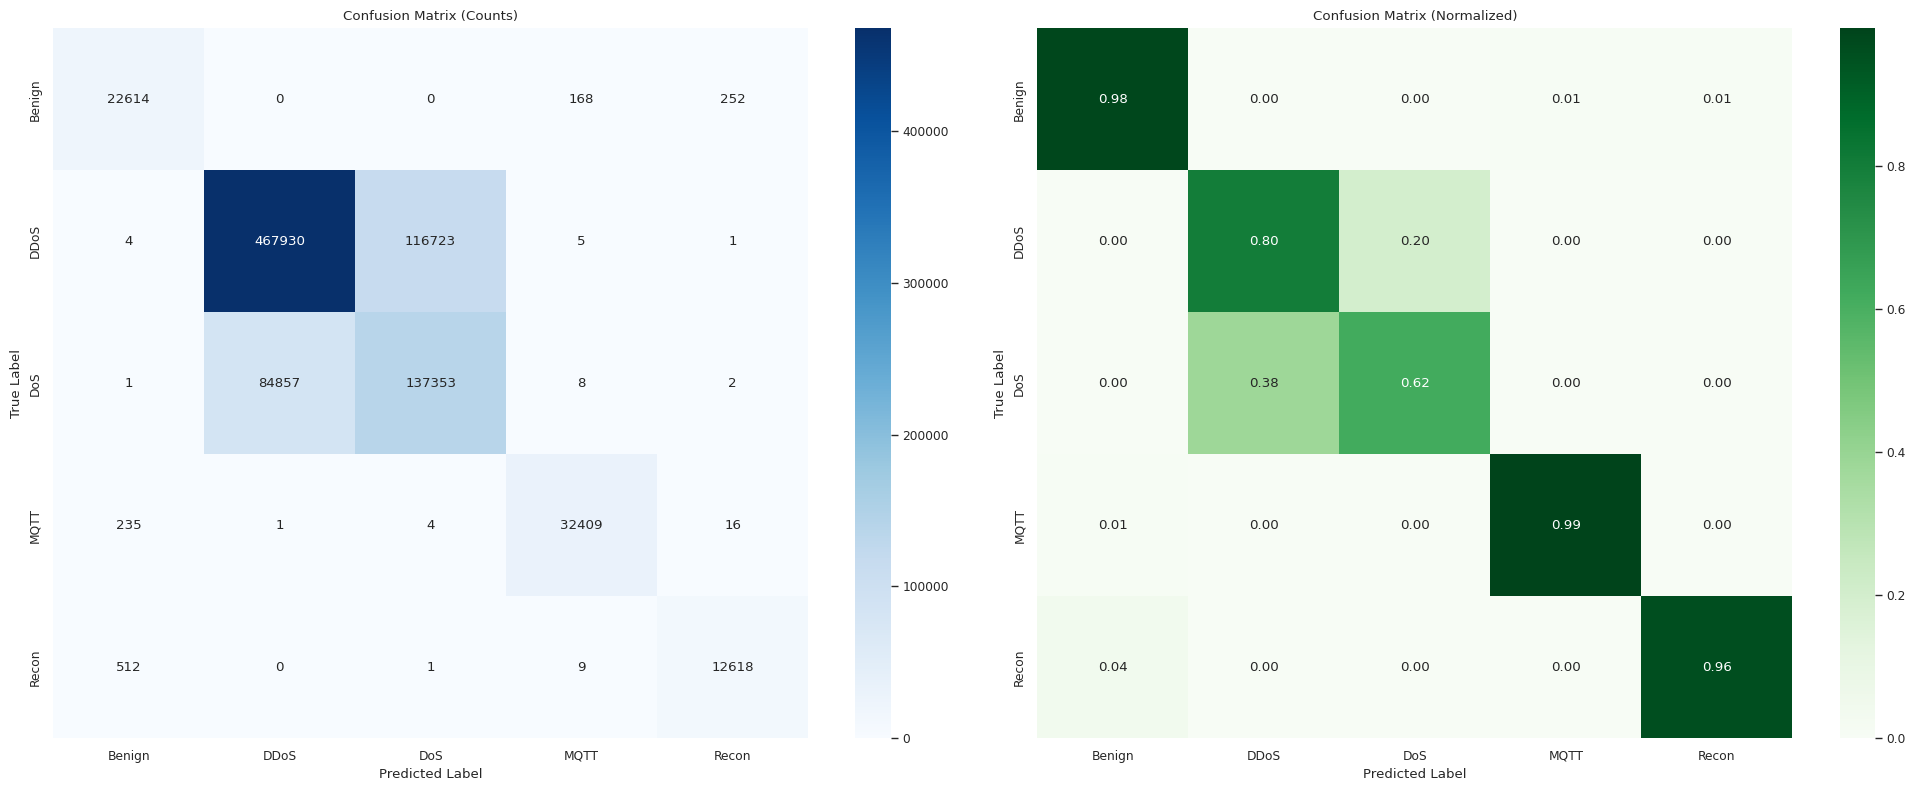

In [17]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [18]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9678    0.9818    0.9747     23034
        DDoS     0.8465    0.8003    0.8228    584663
         DoS     0.5406    0.6181    0.5767    222221
        MQTT     0.9942    0.9922    0.9932     32665
       Recon     0.9790    0.9603    0.9695     13140

    accuracy                         0.7684    875723
   macro avg     0.8656    0.8705    0.8674    875723
weighted avg     0.7796    0.7684    0.7729    875723



In [19]:
f1_score(y_test, y_pred_classes, average="macro")

0.8673917223782647

In [20]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 41s 1ms/step - accuracy: 0.7684 - loss: 0.4737
Test accuracy: 0.7684
